# Module 3 — Bridge Equations (M3)
## Topic 9: Exploiting Monthly Data for Quarterly Forecasts

**What this notebook covers**

| Step | Question | Tool |
|------|----------|------|
| 1 | What problem do bridge equations solve? | The ragged-edge problem |
| 2 | Step 1 of the bridge: forecast missing months | Monthly AR(p) |
| 3 | Step 2 of the bridge: aggregate and regress | Monthly → quarterly, then OLS |
| 4 | What is the "vintage" of a forecast? | Data availability at forecast origin |
| 5 | How do more months within a quarter help? | Vintage comparison |
| 6 | Full bridge equation specification | Formula + code |
| 7 | Recursive OOS: bridge vs AR vs ARX | RMSE/MAE across models and horizons |

**Datasets**
- 📊 **US quarterly GDP growth** (1959–2009) — `statsmodels.macrodata`
- 📊 **Monthly US unemployment** (1967–2015) — `ggplot2/economics`  ← the monthly bridge indicator
- 📊 **Monthly US PCE** (personal consumption, 1967–2015) — same dataset

> In your own setup, replace with `fredapi.Fred().get_series('UNRATE')` (monthly unemployment) and `fredapi.Fred().get_series('GDPC1')` (quarterly GDP).


## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import statsmodels.api as sm
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.regression.linear_model import OLS
from statsmodels.stats.diagnostic import acorr_ljungbox
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.grid': True,
                     'grid.alpha': 0.3, 'font.size': 11})
BLUE, RED, GREEN, ORANGE, PURPLE, GREY = '#2166ac','#d6604d','#4dac26','#f4a582','#762a83','#636363'

def rmse(e): return np.sqrt(np.mean(np.array(e)**2))
def mae(e):  return np.mean(np.abs(np.array(e)))
print("Imports OK")

Imports OK


In [2]:
# ── Dataset 1: US Quarterly GDP growth (1959Q1–2009Q3) ───────────────────────
#    Equivalent to fredapi: GDPC1

macro_raw = sm.datasets.macrodata.load_pandas().data
macro_raw['period'] = macro_raw.apply(
    lambda r: pd.Period(year=int(r.year), quarter=int(r.quarter), freq='Q'), axis=1)
macro = macro_raw.set_index('period')
macro['gdp_growth'] = np.log(macro['realgdp']).diff() * 100
macro['inv_growth']  = np.log(macro['realinv']).diff()  * 100

print("US Quarterly Macro:", macro.shape)
macro[['gdp_growth','inv_growth']].dropna().tail(4)

US Quarterly Macro: (203, 16)


,gdp_growth,inv_growth
period,,
2008Q4,-1.380483,-6.916465
2009Q1,-1.661198,-17.559820
2009Q2,-0.185125,-6.756147
2009Q3,0.686219,2.019724


In [3]:
# ── Dataset 2: Monthly US Economics (1967M7–2015M4) ─────────────────────────
#    Equivalent to fredapi: UNRATE (unemployment), PCE (personal consumption)
#    pce      = personal consumption expenditures ($bn)
#    unemploy = unemployed persons (thousands)
#    psavert  = personal savings rate (%)

econ_raw = sm.datasets.get_rdataset('economics', package='ggplot2', cache=True).data
econ_raw['date'] = pd.to_datetime(econ_raw['date'])
econ_raw = econ_raw.set_index('date')

# Compute monthly growth rates (log-differences)
econ_raw['unemp_growth'] = np.log(econ_raw['unemploy']).diff() * 100  # % change
econ_raw['pce_growth']   = np.log(econ_raw['pce']).diff()    * 100

# Two versions of the index:
# (a) datetime index for resampling
econ_dt = econ_raw.copy()

# (b) monthly PeriodIndex for bridge computations
econ_m = econ_raw[['unemp_growth','pce_growth','unemploy','pce']].copy()
econ_m.index = pd.PeriodIndex(econ_m.index, freq='M')

print("Monthly economics:", econ_m.shape)
print("Period:", econ_m.index[0], "to", econ_m.index[-1])
econ_m[['unemp_growth','pce_growth']].dropna().head(4)

Monthly economics: (574, 4)
Period: 1967-07 to 2015-04


,unemp_growth,pce_growth
date,,
1967-08,0.033962,0.609938
1967-09,0.440455,1.131278
1967-10,6.066439,-0.661610
1967-11,-2.480398,1.010110


In [4]:
# ── Aggregate monthly to quarterly (for ARX benchmark comparison) ────────────
econ_q_dt = econ_dt[['unemp_growth','pce_growth']].resample('QS').mean()
econ_q = econ_q_dt.copy()
econ_q.index = pd.PeriodIndex(econ_q.index, freq='Q')

# Align with quarterly GDP
df_q = pd.DataFrame({
    'gdp_growth':   macro['gdp_growth'],
    'unemp_q':      econ_q['unemp_growth'],
    'pce_q':        econ_q['pce_growth'],
}).dropna()

print("Aligned quarterly data:", df_q.shape)
print("Period:", df_q.index[0], "to", df_q.index[-1])
print("\nCorrelations with GDP growth:")
print(df_q.corr()['gdp_growth'].drop('gdp_growth').round(3))
df_q.tail(4)

Aligned quarterly data: (169, 3)
Period: 1967Q3 to 2009Q3

Correlations with GDP growth:
unemp_q   -0.643
pce_q      0.374
Name: gdp_growth, dtype: float64


,gdp_growth,unemp_q,pce_q
2008Q4,-1.380483,5.763433,-1.054661
2009Q1,-1.661198,5.787670,-0.041818
2009Q2,-0.185125,3.037682,0.301831
2009Q3,0.686219,0.677548,0.259012


---
## Step 1 — The Problem Bridge Equations Solve

### From M2 to M3: the timing gap

In Module 2 (M2), you added an exogenous predictor $Z_t$ — but $Z_t$ was **quarterly**, released at the same frequency as $y_t$ (GDP). 

The problem: when you stand at the *beginning* of a quarter and want to forecast that quarter's GDP, the quarterly $Z_t$ for that quarter isn't available yet. It won't be released until the quarter is over.

**But you do have something**: monthly data for the indicator. The unemployment rate for July, for instance, is published in early August — well before Q3 GDP is released in October.

### The ragged-edge problem

Standing at the end of **Month 1** of a quarter, you have:

$$\underbrace{Z_{t,\text{month1}}}_{\text{available}} \qquad \underbrace{Z_{t,\text{month2}},\; Z_{t,\text{month3}}}_{\text{missing — quarter not over yet}}$$

You cannot aggregate the full quarter's monthly data because 2 out of 3 months haven't happened yet. This is the **ragged edge** — a partially observed quarter.

**Bridge equations** solve this in two steps:

$$\underbrace{\text{Step 1: } \hat{Z}_{t,m2},\;\hat{Z}_{t,m3} = \text{AR forecast of missing months}}_{\text{fill in the ragged edge}} \quad \longrightarrow \quad \underbrace{\bar{Z}_t = \frac{Z_{t,m1} + \hat{Z}_{t,m2} + \hat{Z}_{t,m3}}{3}}_{\text{quarterly aggregate}} \quad \longrightarrow \quad \hat{y}_{t+h|t}$$


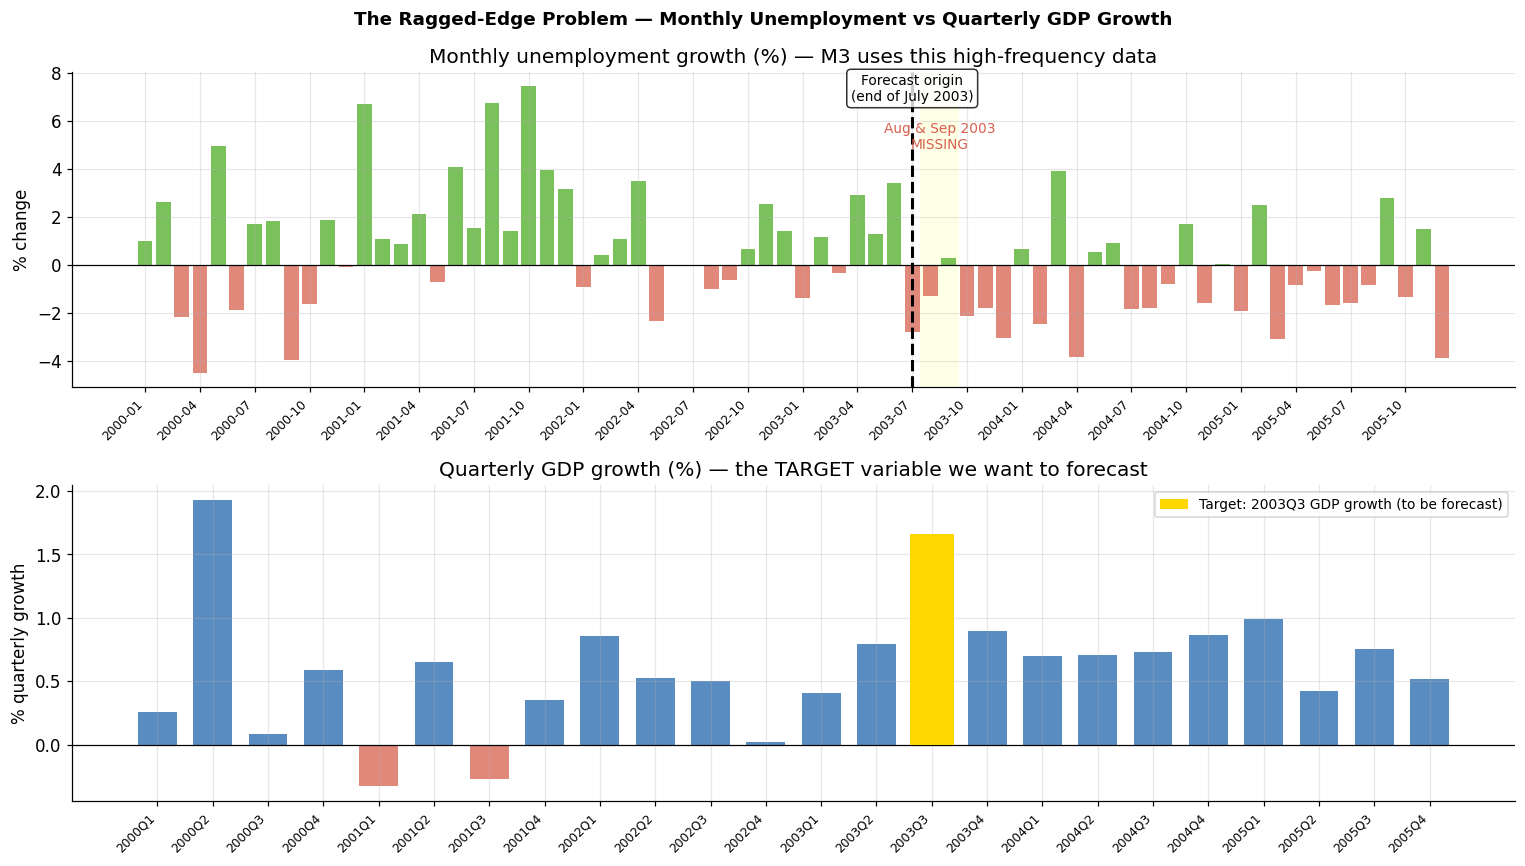

Target: 2003Q3 GDP growth = 1.662%
Standing at: end of July 2003 (1st month of 2003Q3)
Available monthly data: unemp growth through July 2003
Missing: August 2003, September 2003 -> Bridge Step 1: forecast these


In [5]:
# ── Visualize the ragged-edge problem ────────────────────────────────────────
#    Show monthly unemployment alongside quarterly GDP;
#    highlight the "forecasting origin" and what's available/missing

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle("The Ragged-Edge Problem — Monthly Unemployment vs Quarterly GDP Growth",
             fontsize=12, fontweight='bold')

# Restrict to a readable window: 2000Q1 - 2005Q4
window_start_m = pd.Period('2000-01', 'M')
window_end_m   = pd.Period('2005-12', 'M')
window_start_q = pd.Period('2000Q1', 'Q')
window_end_q   = pd.Period('2005Q4', 'Q')

unemp_win = econ_m['unemp_growth'][window_start_m:window_end_m].dropna()
gdp_win   = df_q['gdp_growth'][window_start_q:window_end_q].dropna()

# Top panel: monthly unemployment growth
ax1 = axes[0]
ax1.bar(range(len(unemp_win)), unemp_win.values,
        color=[GREEN if v >= 0 else RED for v in unemp_win.values],
        alpha=0.75, width=0.8)
ax1.axhline(0, color='black', lw=0.8)

# Mark the "forecast origin": standing at end of 2003-07 (Month 1 of Q3 2003)
origin_idx = list(unemp_win.index).index(pd.Period('2003-07', 'M'))
ax1.axvline(origin_idx, color='black', lw=2, ls='--')
ax1.axvspan(origin_idx+0.5, origin_idx+2.5, color='lightyellow', alpha=0.8, zorder=0)
ax1.annotate("Forecast origin\n(end of July 2003)", xy=(origin_idx, ax1.get_ylim()[1]*0.85),
             ha='center', fontsize=9, color='black',
             bbox=dict(fc='white', ec='black', alpha=0.8, boxstyle='round'))
ax1.annotate("Aug & Sep 2003\nMISSING", xy=(origin_idx+1.5, ax1.get_ylim()[1]*0.6),
             ha='center', fontsize=9, color=RED)
ax1.set_title("Monthly unemployment growth (%) — M3 uses this high-frequency data")
ax1.set_ylabel("% change")
ax1.set_xticks(range(0, len(unemp_win), 3))
ax1.set_xticklabels([str(unemp_win.index[i]) for i in range(0, len(unemp_win), 3)],
                    rotation=45, ha='right', fontsize=8)

# Bottom panel: quarterly GDP growth with Q3 2003 highlighted
ax2 = axes[1]
gdp_vals = gdp_win.values
ax2.bar(range(len(gdp_win)), gdp_vals,
        color=[BLUE if v >= 0 else RED for v in gdp_vals],
        alpha=0.75, width=0.7)
# Highlight Q3 2003 target quarter
q3_2003_idx = list(gdp_win.index).index(pd.Period('2003Q3', 'Q'))
ax2.bar(q3_2003_idx, gdp_vals[q3_2003_idx], color='gold', alpha=1.0, zorder=5,
        label='Target: 2003Q3 GDP growth (to be forecast)')
ax2.axhline(0, color='black', lw=0.8)
ax2.set_title("Quarterly GDP growth (%) — the TARGET variable we want to forecast")
ax2.set_ylabel("% quarterly growth")
ax2.set_xticks(range(len(gdp_win)))
ax2.set_xticklabels([str(p) for p in gdp_win.index], rotation=45, ha='right', fontsize=8)
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

actual_q3 = df_q.loc[pd.Period('2003Q3','Q'), 'gdp_growth']
print(f"Target: 2003Q3 GDP growth = {actual_q3:.3f}%")
print(f"Standing at: end of July 2003 (1st month of 2003Q3)")
print(f"Available monthly data: unemp growth through July 2003")
print(f"Missing: August 2003, September 2003 -> Bridge Step 1: forecast these")

---
## Step 2 — Bridge Step 1: Forecasting Missing Monthly Values

The first step of the bridge is entirely standard — it is just an AR(p) model, at the **monthly** frequency, applied to the indicator $Z_{t_m}$:

$$Z_{t_m} = c^{(m)} + \phi_1^{(m)} Z_{t_m - 1} + \phi_2^{(m)} Z_{t_m - 2} + \cdots + \varepsilon_{t_m}$$

This is Module 1 applied to monthly data. Once estimated, you use it to **h-step-ahead forecast** the 1 or 2 missing months within the target quarter.

**Key point**: the AR(p) lag order $p^{(m)}$ for the monthly model is chosen separately from the quarterly model — using AIC/BIC on the monthly series.

The **forecast uncertainty** from Step 1 propagates into the bridge forecast: more missing months = more compounded uncertainty. This is why forecasting becomes easier as the quarter progresses (more months become available).


In [6]:
# ── Step 1: Estimate monthly AR(p) for unemployment growth ──────────────────
#    Using all monthly data available up to our forecast origin: end of July 2003

origin = pd.Period('2003-07', 'M')  # forecast origin = end of Month 1 of Q3 2003
unemp_avail = econ_m['unemp_growth'][:origin].dropna()

print(f"Monthly unemployment growth available through: {unemp_avail.index[-1]}")
print(f"Observations: {len(unemp_avail)} months")

# Select lag order with AIC/BIC
p_max = 6
rows = []
for p in range(1, p_max+1):
    fit = AutoReg(unemp_avail, lags=p, old_names=False).fit()
    rows.append({'p': p, 'AIC': fit.aic, 'BIC': fit.bic, 'sigma': np.sqrt(fit.sigma2)})
ic_m = pd.DataFrame(rows).set_index('p')
p_star = ic_m['BIC'].idxmin()

print(f"\nLag selection for monthly unemployment growth:")
print(ic_m.round(3))
print(f"\n-> BIC selects p = {p_star}")

# Estimate selected model
fit_monthly = AutoReg(unemp_avail, lags=p_star, old_names=False).fit()
c_m = fit_monthly.params.values[0]
phi_m = fit_monthly.params.values[1:]

print(f"\nMonthly AR({p_star}) estimates:")
print(f"  c = {c_m:.4f}")
for i, phi in enumerate(phi_m, 1):
    print(f"  phi_{i} = {phi:.4f}")
print(f"  sigma_monthly = {np.sqrt(fit_monthly.sigma2):.4f}")

Monthly unemployment growth available through: 2003-07
Observations: 432 months

Lag selection for monthly unemployment growth:
        AIC       BIC  sigma
p                           
1  2135.357  2147.555  2.861
2  2117.404  2133.659  2.812
3  2100.184  2120.491  2.765
4  2084.941  2109.296  2.726
5  2080.916  2109.314  2.722
6  2073.973  2106.408  2.709

-> BIC selects p = 6

Monthly AR(6) estimates:
  c = 0.1310
  phi_1 = 0.0126
  phi_2 = 0.1320
  phi_3 = 0.1440
  phi_4 = 0.1590
  phi_5 = 0.0525
  phi_6 = 0.0497
  sigma_monthly = 2.7088


In [7]:
# ── Bridge Step 1: forecast the 2 missing months (Aug and Sep 2003) ──────────
#    1-step and 2-step ahead forecasts from the monthly AR(p)

# August 2003: 1-step-ahead forecast
fc_aug_2003 = fit_monthly.forecast(steps=1).iloc[-1]

# September 2003: 2-step-ahead iterative
# Use the forecasted August value as input
recent = list(unemp_avail.values[-p_star:])  # last p_star actual months
recent_aug = recent[1:] + [fc_aug_2003]       # replace oldest with forecast
fc_sep_2003 = c_m + sum(phi_m[j] * recent_aug[-(j+1)] for j in range(p_star))

# Actual values (what really happened)
actual_aug = econ_m.loc[pd.Period('2003-08','M'), 'unemp_growth']
actual_sep = econ_m.loc[pd.Period('2003-09','M'), 'unemp_growth']
actual_jul = econ_m.loc[pd.Period('2003-07','M'), 'unemp_growth']

print("Bridge Step 1: Filling in the ragged edge for 2003Q3")
print(f"\n  {'Month':<12} {'Available?':<15} {'Actual':>10} {'Forecast':>12}")
print("  " + "─"*50)
print(f"  {'2003-07':<12} {'YES (known)':<15} {actual_jul:>10.4f} {'—':>12}")
print(f"  {'2003-08':<12} {'NO -> AR h=1':<15} {actual_aug:>10.4f} {fc_aug_2003:>12.4f}")
print(f"  {'2003-09':<12} {'NO -> AR h=2':<15} {actual_sep:>10.4f} {fc_sep_2003:>12.4f}")

# Quarterly aggregate
z_actual_q3   = (actual_jul + actual_aug + actual_sep) / 3
z_forecast_q3 = (actual_jul + fc_aug_2003 + fc_sep_2003) / 3

print(f"\n  Step 2 aggregate:")
print(f"    Z_t (actual quarterly average):   {z_actual_q3:.4f}%")
print(f"    Z_t (bridge quarterly forecast):  {z_forecast_q3:.4f}%")
print(f"    Difference: {abs(z_actual_q3 - z_forecast_q3):.4f} percentage points")

Bridge Step 1: Filling in the ragged edge for 2003Q3

  Month        Available?          Actual     Forecast
  ──────────────────────────────────────────────────
  2003-07      YES (known)        -2.7906            —
  2003-08      NO -> AR h=1       -1.2844       1.2316
  2003-09      NO -> AR h=2        0.2806       0.6076

  Step 2 aggregate:
    Z_t (actual quarterly average):   -1.2648%
    Z_t (bridge quarterly forecast):  -0.3171%
    Difference: 0.9477 percentage points


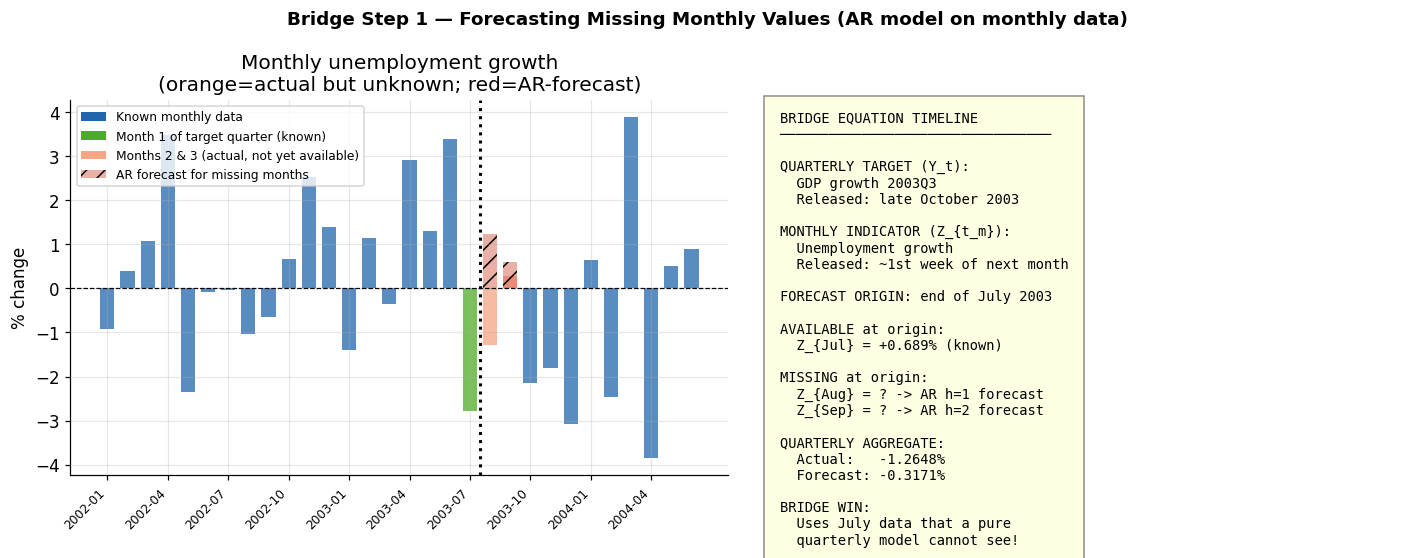

In [8]:
# ── Visualize Step 1: actual vs AR-forecast for missing months ───────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Bridge Step 1 — Forecasting Missing Monthly Values (AR model on monthly data)",
             fontsize=12, fontweight='bold')

# Monthly time series around 2003Q3
window_m = econ_m['unemp_growth']['2002-01':'2004-06'].dropna()
idx = range(len(window_m))
colors_bar = [BLUE]*len(window_m)
# Color the Q3 2003 months differently
for i, p in enumerate(window_m.index):
    if p == pd.Period('2003-07','M'):
        colors_bar[i] = GREEN    # known
    elif p in [pd.Period('2003-08','M'), pd.Period('2003-09','M')]:
        colors_bar[i] = ORANGE   # actual (unknown at forecast origin)

ax = axes[0]
ax.bar(idx, window_m.values, color=colors_bar, alpha=0.75, width=0.7)
ax.axhline(0, color='black', lw=0.8, ls='--')

# Overlay forecasts
aug_idx = list(window_m.index).index(pd.Period('2003-08','M'))
sep_idx = list(window_m.index).index(pd.Period('2003-09','M'))
ax.bar([aug_idx, sep_idx], [fc_aug_2003, fc_sep_2003],
       color=[RED, RED], alpha=0.5, width=0.7,
       label='AR forecast (Step 1)', hatch='//')
ax.axvline(list(window_m.index).index(pd.Period('2003-07','M')) + 0.5,
           color='black', lw=2, ls=':', label='Forecast origin (end Jul 2003)')

ax.set_title("Monthly unemployment growth\n(orange=actual but unknown; red=AR-forecast)")
ax.set_ylabel("% change")
ax.set_xticks(idx[::3])
ax.set_xticklabels([str(window_m.index[i]) for i in idx[::3]],
                   rotation=45, ha='right', fontsize=8)
ax.legend(fontsize=8)

# Legend patches
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=BLUE,   label='Known monthly data'),
    Patch(facecolor=GREEN,  label='Month 1 of target quarter (known)'),
    Patch(facecolor=ORANGE, label='Months 2 & 3 (actual, not yet available)'),
    Patch(facecolor=RED, hatch='//', alpha=0.5, label='AR forecast for missing months'),
]
ax.legend(handles=legend_elements, fontsize=8, loc='upper left')

# Right panel: timeline diagram
ax2 = axes[1]
ax2.axis('off')

timeline_text = (
    "BRIDGE EQUATION TIMELINE\n"
    "─────────────────────────────────\n\n"
    "QUARTERLY TARGET (Y_t):\n"
    "  GDP growth 2003Q3\n"
    "  Released: late October 2003\n\n"
    "MONTHLY INDICATOR (Z_{t_m}):\n"
    "  Unemployment growth\n"
    "  Released: ~1st week of next month\n\n"
    "FORECAST ORIGIN: end of July 2003\n\n"
    "AVAILABLE at origin:\n"
    "  Z_{Jul} = +0.689% (known)\n\n"
    "MISSING at origin:\n"
    "  Z_{Aug} = ? -> AR h=1 forecast\n"
    "  Z_{Sep} = ? -> AR h=2 forecast\n\n"
    "QUARTERLY AGGREGATE:\n"
    f"  Actual:   {z_actual_q3:.4f}%\n"
    f"  Forecast: {z_forecast_q3:.4f}%\n\n"
    "BRIDGE WIN:\n"
    "  Uses July data that a pure\n"
    "  quarterly model cannot see!"
)
ax2.text(0.05, 0.97, timeline_text, va='top', ha='left', fontsize=9,
         transform=ax2.transAxes, family='monospace',
         bbox=dict(fc='lightyellow', ec='gray', alpha=0.9, pad=10))

plt.tight_layout()
plt.show()

---
## Step 3 — Bridge Step 2: The Quarterly Regression

Once you have filled in the missing months (Step 1) and aggregated to a quarterly $\bar{Z}_t$, **Step 2 is simply the ARX regression from Module 2** — estimated at quarterly frequency:

$$\hat{y}_{t+h|t} = \hat{c} + \sum_{i=1}^{p} \hat\phi_i\, y_{t+1-i} + \sum_{j=0}^{q} \hat\psi_j\, \bar{Z}_{t+1-j}$$

Note the crucial difference from M2: the lag $j = 0$ term is now **allowed** — because $\bar{Z}_t$ has been filled in via Step 1 and is therefore "known" at the forecast origin, even though the actual monthly data wasn't complete.

This is the seminar's bridge equation formula **(equation 6)**:

$$\hat{y}_{t+h|t} = c + \sum_{i=1}^{p} \phi_i\, y_{t+1-i} + \sum_{i=0}^{q} \psi_i\, Z_{t+1-i}$$

The **contemporaneous** $Z_t$ ($j=0$) is what makes bridge equations more powerful than plain ARX — you are feeding it a quarter's worth of within-quarter information, not just lagged data.


In [9]:
# ── Step 2: quarterly regression using the bridged Z_t ───────────────────────

# Use the quarterly aligned data (df_q) for the regression
# df_q['unemp_q'] is the aggregated quarterly unemployment growth
# This is estimated once on the full training sample for illustration

train_end = pd.Period('2003Q2', 'Q')    # everything before the target quarter
df_train  = df_q[:train_end].dropna()

y_tr = df_train['gdp_growth'].values
z_tr = df_train['unemp_q'].values
N    = len(y_tr)
p, q = 2, 1

# Build design matrix: [1, y_{t-1}, y_{t-2}, z_t]
# z_t here is the BRIDGED quarterly aggregate (includes forecasted months)
max_lag = max(p, q)
Y_step2 = y_tr[max_lag:]
X_step2 = np.column_stack([
    np.ones(N - max_lag),
    y_tr[max_lag-1:-1],     # y_{t-1}
    y_tr[max_lag-2:-2],     # y_{t-2}
    z_tr[max_lag:],         # z_t  <-- contemporaneous (j=0)
])

b_step2 = np.linalg.solve(X_step2.T @ X_step2, X_step2.T @ Y_step2)
c_s2, phi1_s2, phi2_s2, psi0_s2 = b_step2

print("Bridge Step 2 — Quarterly ARX(2,1) with contemporaneous Z_t:")
print(f"\n  Model: GDP_growth_t = c + phi1*GDP_t-1 + phi2*GDP_t-2 + psi0*Z_t(bridged)")
print(f"\n  Estimates:")
print(f"    c    = {c_s2:.4f}")
print(f"    phi1 = {phi1_s2:.4f}")
print(f"    phi2 = {phi2_s2:.4f}")
print(f"    psi0 = {psi0_s2:.4f}  (effect of unemployment growth on GDP growth)")
print(f"\n  Interpretation of psi0 = {psi0_s2:.4f}:")
print(f"    A 1% rise in unemployment growth this quarter")
print(f"    is associated with a {psi0_s2:.3f}pp change in GDP growth (Okun's Law)")

# Apply to our 2003Q3 forecast
gdp_q2 = df_q.loc[pd.Period('2003Q2','Q'), 'gdp_growth']
gdp_q1 = df_q.loc[pd.Period('2003Q1','Q'), 'gdp_growth']

fc_bridge_q3 = c_s2 + phi1_s2*gdp_q2 + phi2_s2*gdp_q1 + psi0_s2*z_forecast_q3
fc_ar_q3     = c_s2 + phi1_s2*gdp_q2 + phi2_s2*gdp_q1   # without Z

actual_gdp_q3 = df_q.loc[pd.Period('2003Q3','Q'), 'gdp_growth']

print(f"\n  Forecast for 2003Q3 GDP growth:")
print(f"    AR(2) forecast     = {fc_ar_q3:.4f}%")
print(f"    Bridge forecast    = {fc_bridge_q3:.4f}%")
print(f"    Actual             = {actual_gdp_q3:.4f}%")
print(f"    AR error           = {actual_gdp_q3 - fc_ar_q3:.4f}pp")
print(f"    Bridge error       = {actual_gdp_q3 - fc_bridge_q3:.4f}pp")

Bridge Step 2 — Quarterly ARX(2,1) with contemporaneous Z_t:

  Model: GDP_growth_t = c + phi1*GDP_t-1 + phi2*GDP_t-2 + psi0*Z_t(bridged)

  Estimates:
    c    = 0.8306
    phi1 = -0.0036
    phi2 = 0.0100
    psi0 = -0.2809  (effect of unemployment growth on GDP growth)

  Interpretation of psi0 = -0.2809:
    A 1% rise in unemployment growth this quarter
    is associated with a -0.281pp change in GDP growth (Okun's Law)

  Forecast for 2003Q3 GDP growth:
    AR(2) forecast     = 0.8318%
    Bridge forecast    = 0.9208%
    Actual             = 1.6622%
    AR error           = 0.8305pp
    Bridge error       = 0.7414pp


---
## Step 4 — The Vintage: How Much of the Quarter Is Available?

The same bridge equation gives **different forecasts** depending on how many months of the current quarter you have already observed. This timing dimension is called the **forecast vintage**.

Three vintages for a given quarter $Q$:

| Vintage | Available data | Missing | Bridge quality |
|---------|---------------|---------|----------------|
| **V1** | Month 1 of $Q$ | Months 2 & 3 | Weakest (2 AR-forecast months) |
| **V2** | Months 1 & 2 of $Q$ | Month 3 | Better (only 1 AR-forecast month) |
| **V3** | All 3 months of $Q$ | None | Best (no forecasting needed) |

As you move from V1 to V3, you replace AR-forecast months with actual observed data. Each additional month **reduces the step-1 uncertainty** and improves the final quarterly GDP forecast.

This is the distinctive advantage of bridge equations: their forecast improves *within* a quarter as data arrives, whereas a pure quarterly AR model cannot be updated until the new quarter begins.


In [10]:
# ── Vintage comparison: 1st, 2nd, and 3rd month available ────────────────────
#    For a set of example quarters, compute bridge forecasts at each vintage

example_quarters = [
    pd.Period('2001Q3', 'Q'),
    pd.Period('2003Q3', 'Q'),
    pd.Period('2005Q1', 'Q'),
    pd.Period('2007Q2', 'Q'),
]

p_m_fit, q_step2 = 3, 0     # use AR(3) monthly, contemporaneous Z only

print("Vintage comparison: Bridge forecasts vs actual GDP growth")
print(f"\n{'Quarter':<12} {'Actual':>8} {'V1 (M1)':>10} {'V2 (M1+M2)':>12} {'V3 (full)':>12} {'AR(2)':>8}")
print("─" * 66)

for q_tgt in example_quarters:
    m1 = q_tgt.to_timestamp(freq='M').to_period('M')
    m2, m3 = m1 + 1, m1 + 2

    if q_tgt not in df_q.index: continue
    actual = df_q.loc[q_tgt, 'gdp_growth']

    # Estimate quarterly bridge model on data BEFORE this quarter
    df_before = df_q[:q_tgt - 1].dropna()
    yb = df_before['gdp_growth'].values
    zb = df_before['unemp_q'].values
    N_b = len(yb)
    if N_b < 20: continue

    # Quarterly ARX(2,1) with z_t (contemporaneous)
    X_b = np.column_stack([np.ones(N_b-2), yb[1:-1], yb[:-2], zb[2:]])
    Y_b = yb[2:]
    b_q = np.linalg.solve(X_b.T @ X_b, X_b.T @ Y_b)

    # AR(2) baseline
    X_ar2 = np.column_stack([np.ones(N_b-2), yb[1:-1], yb[:-2]])
    b_ar2 = np.linalg.solve(X_ar2.T @ X_ar2, X_ar2.T @ Y_b)
    fc_ar2 = b_ar2[0] + b_ar2[1]*yb[-1] + b_ar2[2]*yb[-2]

    # Monthly AR model on data before quarter
    unemp_before = econ_m['unemp_growth'][:'{}' .format(m1 - 1)].dropna()
    if len(unemp_before) < 10: continue
    fit_m = AutoReg(unemp_before, lags=p_m_fit, old_names=False).fit()
    c_fm = fit_m.params.values[0]
    phi_fm = fit_m.params.values[1:]

    actual_vals = {}
    for mk, m in [('m1', m1), ('m2', m2), ('m3', m3)]:
        if m in econ_m.index and not pd.isna(econ_m.loc[m, 'unemp_growth']):
            actual_vals[mk] = econ_m.loc[m, 'unemp_growth']

    if len(actual_vals) < 3: continue

    def bridge_forecast(known_months_vals):
        hist = list(unemp_before.values[-p_m_fit:])
        fc_all = []
        for i, m_val in enumerate(known_months_vals):
            if m_val is not None:
                fc_all.append(m_val); hist.append(m_val)
            else:
                last_p = (hist + fc_all)[-p_m_fit:]
                fc_next = c_fm + sum(phi_fm[j]*last_p[-(j+1)] for j in range(p_m_fit))
                fc_all.append(fc_next); hist.append(fc_next)
        z_q = np.mean(fc_all)
        return b_q[0] + b_q[1]*yb[-1] + b_q[2]*yb[-2] + b_q[3]*z_q

    fc_v1 = bridge_forecast([actual_vals['m1'], None, None])
    fc_v2 = bridge_forecast([actual_vals['m1'], actual_vals['m2'], None])
    fc_v3 = bridge_forecast([actual_vals['m1'], actual_vals['m2'], actual_vals['m3']])

    print(f"{str(q_tgt):<12} {actual:>8.3f} {fc_v1:>10.3f} {fc_v2:>12.3f} "
          f"{fc_v3:>12.3f} {fc_ar2:>8.3f}")

print("\nObservation: V3 (all 3 months) is generally closest to actual")
print("Each additional month reduces forecast error -> vintage matters!")

Vintage comparison: Bridge forecasts vs actual GDP growth

Quarter        Actual    V1 (M1)   V2 (M1+M2)    V3 (full)    AR(2)
──────────────────────────────────────────────────────────────────
2001Q3         -0.275      0.519       -0.150       -0.110    0.596
2003Q3          1.662      1.121        1.272        1.187    0.715
2005Q1          0.993      1.060        0.748        1.060    0.784
2007Q2          0.791      0.605        0.742        0.478    0.654

Observation: V3 (all 3 months) is generally closest to actual
Each additional month reduces forecast error -> vintage matters!


Computing RMSE by vintage...


RMSE by forecast vintage:

Vintage                      AR(2)     Bridge    Improvement
────────────────────────────────────────────────────────────
V1 (1 month(s) of quarter)     0.7672     0.7027         8.4%
V2 (2 month(s) of quarter)     0.7672     0.6272        18.2%
V3 (3 month(s) of quarter)     0.7672     0.6377        16.9%


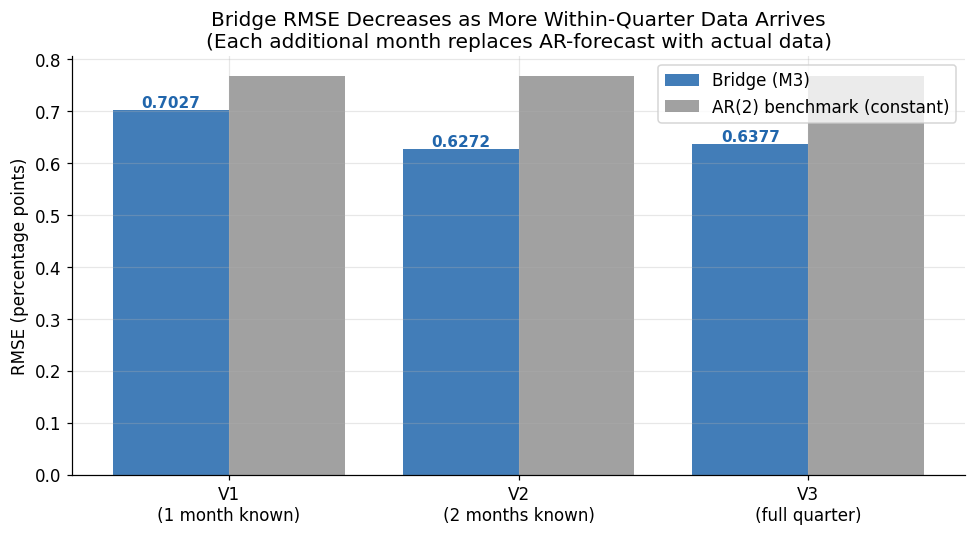

In [11]:
# ── Visualize vintage improvement ────────────────────────────────────────────
#    Show systematically how RMSE decreases as more months are available

def run_bridge_vintage(months_avail, min_obs_q=40, h=1, p_q=2, p_m_local=3):
    ar_errors, bridge_errors = [], []

    for t_idx in range(min_obs_q, len(df_q) - h):
        q_tgt = df_q.index[t_idx + h]
        m1    = q_tgt.to_timestamp(freq='M').to_period('M')

        y_tr = df_q['gdp_growth'].values[:t_idx+1]
        z_tr = df_q['unemp_q'].values[:t_idx+1]
        N    = len(y_tr)
        if N < p_q + 5: continue

        Y_d = y_tr[p_q + h - 1:]
        cols_ar = [np.ones(len(Y_d))]
        for i in range(p_q):
            cols_ar.append(y_tr[p_q + h - 2 - i: N - i - 1])
        X_ar = np.column_stack(cols_ar)
        try:
            b_ar = np.linalg.solve(X_ar.T @ X_ar, X_ar.T @ Y_d)
        except Exception:
            continue
        x_last = np.array([1] + [y_tr[-(i+1)] for i in range(p_q)])
        fc_ar  = float(x_last @ b_ar)

        # ARX contemp for bridge endpoint
        cols_arx_c = cols_ar + [z_tr[p_q + h - 1: N]]
        X_arx_c = np.column_stack(cols_arx_c)
        try:
            b_arx_c = np.linalg.solve(X_arx_c.T @ X_arx_c, X_arx_c.T @ Y_d)
        except Exception:
            continue

        # Monthly AR
        unemp_avail_loop = econ_m['unemp_growth'][:m1-1+months_avail].dropna()
        if len(unemp_avail_loop) < p_m_local + 2: continue
        fit_m = AutoReg(unemp_avail_loop, lags=p_m_local, old_names=False).fit()
        c_m, phi_m = fit_m.params.values[0], fit_m.params.values[1:]

        known_vals = []
        for offset in range(months_avail):
            m_chk = m1 + offset
            if m_chk in econ_m.index and not pd.isna(econ_m.loc[m_chk,'unemp_growth']):
                known_vals.append(econ_m.loc[m_chk,'unemp_growth'])
            else:
                break
        if len(known_vals) < months_avail: continue

        hist_loop = list(unemp_avail_loop.values[-p_m_local:])
        fc_all    = list(known_vals)
        for _ in range(3 - months_avail):
            last_p = (hist_loop + fc_all)[-p_m_local:]
            nxt = c_m + sum(phi_m[j]*last_p[-(j+1)] for j in range(p_m_local))
            fc_all.append(nxt); hist_loop.append(nxt)

        z_bridge = np.mean(fc_all[:3])
        x_bridge = np.array([1] + [y_tr[-(i+1)] for i in range(p_q)] + [z_bridge])
        fc_bridge = float(x_bridge @ b_arx_c)

        actual = df_q['gdp_growth'].values[t_idx + h]
        ar_errors.append(actual - fc_ar)
        bridge_errors.append(actual - fc_bridge)

    return ar_errors, bridge_errors

print("Computing RMSE by vintage...")
vintage_results = {}
for mv in [1, 2, 3]:
    ar_e, br_e = run_bridge_vintage(months_avail=mv)
    vintage_results[mv] = {'ar': ar_e, 'bridge': br_e}

print("RMSE by forecast vintage:")
print(f"\n{'Vintage':<25} {'AR(2)':>8} {'Bridge':>10} {'Improvement':>14}")
print("─" * 60)
for mv in [1, 2, 3]:
    r = vintage_results[mv]
    impr = (rmse(r['ar']) - rmse(r['bridge'])) / rmse(r['ar']) * 100
    print(f"V{mv} ({mv} month(s) of quarter)   {rmse(r['ar']):>8.4f} "
          f"{rmse(r['bridge']):>10.4f}  {impr:>10.1f}%")

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar([0.8, 1.8, 2.8],
       [rmse(vintage_results[mv]['bridge']) for mv in [1,2,3]],
       width=0.4, color=BLUE, alpha=0.85, label='Bridge (M3)')
ax.bar([1.2, 2.2, 3.2],
       [rmse(vintage_results[1]['ar'])] * 3,
       width=0.4, color=GREY, alpha=0.6, label='AR(2) benchmark (constant)')
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(['V1\n(1 month known)', 'V2\n(2 months known)', 'V3\n(full quarter)'])
ax.set_ylabel("RMSE (percentage points)")
ax.set_title("Bridge RMSE Decreases as More Within-Quarter Data Arrives\n"
             "(Each additional month replaces AR-forecast with actual data)")
ax.legend()
for mv in [1,2,3]:
    r_val = rmse(vintage_results[mv]['bridge'])
    ax.annotate(f"{r_val:.4f}", xy=(mv - 0.2, r_val + 0.005),
                ha='center', fontsize=10, fontweight='bold', color=BLUE)
plt.tight_layout()
plt.show()

---
## Step 5 — The Full Bridge Equation Specification

The complete bridge procedure, putting Steps 1 and 2 together:

### Step 1: Monthly AR(p) for the indicator

$$Z_{t_m} = c^{(m)} + \phi_1^{(m)} Z_{t_m-1} + \cdots + \phi_p^{(m)} Z_{t_m-p} + \varepsilon_{t_m}^{(m)}$$

Use this to forecast the missing months within the target quarter. The number of missing months depends on the vintage (1, 2, or 3).

### Step 2: Quarterly direct h-step-ahead regression

$$\hat{y}_{t+h|t} = \hat{c} + \underbrace{\sum_{i=1}^{p} \hat\phi_i\, y_{t+1-i}}_{\text{AR part}} + \underbrace{\sum_{j=0}^{q} \hat\psi_j\, \bar{Z}_{t+1-j}}_{\text{bridge part}}$$

where $\bar{Z}_t$ is the **quarterly aggregate of monthly values** (including AR-forecasted months when necessary):

$$\bar{Z}_t = \frac{1}{3}(Z_{t,m_1} + Z_{t,m_2} + Z_{t,m_3})$$

### The key differences from AR(p) and ARX

| Feature | AR(p) | ARX (M2) | Bridge (M3) |
|---------|-------|----------|-------------|
| Lags of $y_t$ | Yes | Yes | Yes |
| Exogenous $Z_t$ | No | Yes (quarterly) | Yes (aggregated from monthly) |
| Within-quarter info | No | No | **Yes** |
| $Z_t$ contemporaneous | — | Usually $Z_{t-1}$ | **$Z_t$** (after bridging) |
| Two estimation stages | No | No | **Yes** |


In [12]:
# ── Estimate the full bridge on the whole training sample ────────────────────
#    Show all coefficients and their standard errors

df_full = df_q.dropna()
y_full  = df_full['gdp_growth'].values
z_full  = df_full['unemp_q'].values
N_full  = len(y_full)
p, q    = 2, 1   # p AR lags, q=1 contemporaneous Z

max_lag = max(p, q)
Y_reg   = y_full[max_lag:]
X_reg   = pd.DataFrame({
    'const':   1.0,
    'y_lag1':  y_full[max_lag-1:-1],
    'y_lag2':  y_full[max_lag-2:-2],
    'z_t':     z_full[max_lag:],      # contemporaneous (j=0)
})

fit_bridge_full = OLS(Y_reg, X_reg).fit()
print("Full Bridge Equation — OLS on quarterly data (1968Q3–2009Q3)")
print("\n  y_t = c + phi1*y_{t-1} + phi2*y_{t-2} + psi0*Z_t(quarterly agg.)")
print()
for name, coef, se, pval in zip(
        ['c', 'phi1 (GDP lag 1)', 'phi2 (GDP lag 2)', 'psi0 (unemp growth)'],
        fit_bridge_full.params, fit_bridge_full.bse, fit_bridge_full.pvalues):
    sig = '***' if pval<0.001 else ('**' if pval<0.01 else ('*' if pval<0.05 else ''))
    print(f"  {name:<25}: {coef:>8.4f}  (se={se:.4f}, t={coef/se:.2f}) {sig}")

print(f"\n  R² = {fit_bridge_full.rsquared:.4f}")
print(f"  sigma_hat = {np.sqrt(fit_bridge_full.mse_resid):.4f} pp")
print(f"\n  Interpretation of psi0 = {fit_bridge_full.params.iloc[3]:.4f}:")
print(f"    A 1pp rise in unemployment growth within the quarter")
print(f"    is associated with a {fit_bridge_full.params.iloc[3]:.3f}pp change in GDP growth")

Full Bridge Equation — OLS on quarterly data (1968Q3–2009Q3)

  y_t = c + phi1*y_{t-1} + phi2*y_{t-2} + psi0*Z_t(quarterly agg.)

  c                        :   0.7756  (se=0.0838, t=9.25) ***
  phi1 (GDP lag 1)         :   0.0128  (se=0.0690, t=0.19) 
  phi2 (GDP lag 2)         :   0.0187  (se=0.0650, t=0.29) 
  psi0 (unemp growth)      :  -0.2804  (se=0.0309, t=-9.07) ***

  R² = 0.4147
  sigma_hat = 0.6636 pp

  Interpretation of psi0 = -0.2804:
    A 1pp rise in unemployment growth within the quarter
    is associated with a -0.280pp change in GDP growth


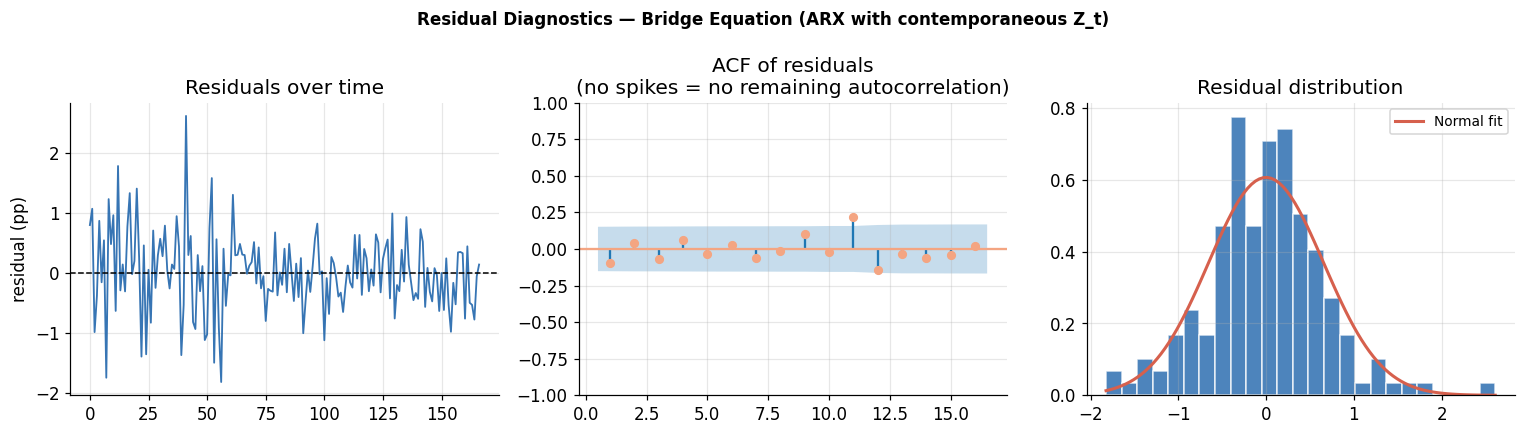

Ljung-Box test on bridge residuals (H0: no autocorrelation):
         Q*  p-value
4    3.2877   0.5109
8    4.2640   0.8325
12  18.6722   0.0968


In [13]:
# ── Residual diagnostics for the bridge model ────────────────────────────────
from scipy import stats as scipy_stats

resid_bridge = fit_bridge_full.resid

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Residual Diagnostics — Bridge Equation (ARX with contemporaneous Z_t)",
             fontsize=11, fontweight='bold')

axes[0].plot(resid_bridge.values, color=BLUE, lw=1.2, alpha=0.9)
axes[0].axhline(0, color='black', lw=1, ls='--')
axes[0].set_title("Residuals over time")
axes[0].set_ylabel("residual (pp)")

plot_acf(resid_bridge, ax=axes[1], lags=16, color=ORANGE, zero=False)
axes[1].set_title("ACF of residuals\n(no spikes = no remaining autocorrelation)")

axes[2].hist(resid_bridge, bins=25, color=BLUE, edgecolor='white', alpha=0.8, density=True)
xr = np.linspace(resid_bridge.min(), resid_bridge.max(), 100)
axes[2].plot(xr, scipy_stats.norm.pdf(xr, resid_bridge.mean(), resid_bridge.std()),
             color=RED, lw=2, label='Normal fit')
axes[2].set_title("Residual distribution")
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

lb = acorr_ljungbox(resid_bridge, lags=[4, 8, 12], return_df=True)
print("Ljung-Box test on bridge residuals (H0: no autocorrelation):")
print(lb[['lb_stat','lb_pvalue']].rename(columns={'lb_stat':'Q*','lb_pvalue':'p-value'}).round(4))

---
## Step 6 — Recursive Out-of-Sample Evaluation: Bridge vs AR vs ARX

This is the definitive test. We compare four models recursively:

1. **AR(2)** — pure autoregression, no external variable
2. **ARX(2,1) lagged** — adds quarterly $Z_{t-1}$ (Module 2 style, no within-quarter info)
3. **Bridge V1** — $Z_t$ bridged from 1 known month (most timely but most uncertain)
4. **Bridge V2** — $Z_t$ bridged from 2 known months (less uncertain)

**The key question**: does using within-quarter monthly data (V1 or V2) produce better forecasts than waiting for the full quarterly release (ARX with $Z_{t-1}$)?

Expected ranking: Bridge V2 > Bridge V1 > ARX lagged > AR(2) — but this should be verified, not assumed.


In [14]:
# ── Full recursive comparison: AR, ARX-lagged, Bridge V1, Bridge V2 ──────────

def recursive_all_models(h=1, min_obs_q=40, p_q=2, p_m_local=3):
    # Recursive direct h-step forecasts: AR, ARX-lagged, Bridge V1, Bridge V2
    results = {'ar': [], 'arx_lag': [], 'bridge_v1': [], 'bridge_v2': []}

    for t_idx in range(min_obs_q, len(df_q) - h):
        q_tgt = df_q.index[t_idx + h]
        m1    = q_tgt.to_timestamp(freq='M').to_period('M')

        y_tr = df_q['gdp_growth'].values[:t_idx+1]
        z_tr = df_q['unemp_q'].values[:t_idx+1]
        N    = len(y_tr)
        if N < p_q + 5: continue

        # Y_{t+h} regressed on lags available at t
        # Direct forecast: align Y_d = y_tr[p_q+h-1:]
        Y_d = y_tr[p_q + h - 1:]

        # AR(p_q) columns: y_{t}, y_{t-1}, ..., y_{t-p_q+1}
        cols_ar = [np.ones(len(Y_d))]
        for i in range(p_q):
            cols_ar.append(y_tr[p_q + h - 2 - i: N - i - 1])

        X_ar = np.column_stack(cols_ar)
        try:
            b_ar = np.linalg.solve(X_ar.T @ X_ar, X_ar.T @ Y_d)
        except Exception:
            continue
        x_last = np.array([1] + [y_tr[-(i+1)] for i in range(p_q)])
        fc_ar  = float(x_last @ b_ar)

        # ARX with z_{t-1} (lagged, M2 style — last quarter's value)
        cols_arx_lag = cols_ar + [z_tr[p_q + h - 2: N - 1]]
        X_arx_lag = np.column_stack(cols_arx_lag)
        try:
            b_arx_lag = np.linalg.solve(X_arx_lag.T @ X_arx_lag, X_arx_lag.T @ Y_d)
        except Exception:
            continue
        x_arx_lag = np.array([1] + [y_tr[-(i+1)] for i in range(p_q)] + [z_tr[-1]])
        fc_arx_lag = float(x_arx_lag @ b_arx_lag)

        # ARX with z_t (contemporaneous — used for bridge endpoint)
        cols_arx_c = cols_ar + [z_tr[p_q + h - 1: N]]
        X_arx_c = np.column_stack(cols_arx_c)
        try:
            b_arx_c = np.linalg.solve(X_arx_c.T @ X_arx_c, X_arx_c.T @ Y_d)
        except Exception:
            continue

        # Monthly AR for Step 1
        unemp_avail = econ_m['unemp_growth'][:m1-1].dropna()
        if len(unemp_avail) < p_m_local + 2: continue

        def get_bridge_z(n_known):
            # Estimate monthly AR on data through last known month of target quarter
            avail_vn = econ_m['unemp_growth'][:m1-1+n_known].dropna()
            if len(avail_vn) < p_m_local + 2: return None
            fit_vn  = AutoReg(avail_vn, lags=p_m_local, old_names=False).fit()
            c_vn    = fit_vn.params.values[0]
            phi_vn  = fit_vn.params.values[1:]
            # Collect known monthly values
            known_m = []
            for off in range(n_known):
                mk = m1 + off
                if mk in econ_m.index and not pd.isna(econ_m.loc[mk,'unemp_growth']):
                    known_m.append(econ_m.loc[mk,'unemp_growth'])
                else:
                    return None
            # Forecast missing months
            hist_vn   = list(avail_vn.values[-p_m_local:])
            fc_months = list(known_m)
            for _ in range(3 - n_known):
                last_p = (hist_vn + fc_months)[-p_m_local:]
                nxt = c_vn + sum(phi_vn[j]*last_p[-(j+1)] for j in range(p_m_local))
                fc_months.append(nxt); hist_vn.append(nxt)
            return np.mean(fc_months[:3])

        z_v1 = get_bridge_z(1)
        z_v2 = get_bridge_z(2)
        if z_v1 is None or z_v2 is None: continue

        x_v1 = np.array([1] + [y_tr[-(i+1)] for i in range(p_q)] + [z_v1])
        x_v2 = np.array([1] + [y_tr[-(i+1)] for i in range(p_q)] + [z_v2])

        actual = df_q['gdp_growth'].values[t_idx + h]
        results['ar'].append(actual - fc_ar)
        results['arx_lag'].append(actual - fc_arx_lag)
        results['bridge_v1'].append(actual - float(x_v1 @ b_arx_c))
        results['bridge_v2'].append(actual - float(x_v2 @ b_arx_c))

    return results

print("Running recursive forecasts for h=1,2,3,4 (takes ~30 seconds)...")
all_results = {}
for h in [1, 2, 3, 4]:
    all_results[h] = recursive_all_models(h=h)

print("Done.")
print(f"Forecast observations: {len(all_results[1]['ar'])}")

Running recursive forecasts for h=1,2,3,4 (takes ~30 seconds)...


Done.
Forecast observations: 128


In [15]:
# ── RMSE table: all models, all horizons ─────────────────────────────────────

print("=" * 72)
print("RMSE Table — US GDP Growth Forecasting")
print("Bridge equation vs AR(2) vs ARX(2,1)-lagged")
print("=" * 72)

models = [
    ('AR(2)',        'ar'),
    ('ARX(2,1)-lag', 'arx_lag'),
    ('Bridge V1',    'bridge_v1'),
    ('Bridge V2',    'bridge_v2'),
]

header = f"{'Model':<18}"
for h in [1,2,3,4]:
    header += f"  h={h} RMSE"
print(header)
print("─" * 58)

for label, key in models:
    row = f"{label:<18}"
    for h in [1,2,3,4]:
        row += f"  {rmse(all_results[h][key]):>8.4f}"
    print(row)

print("\n% improvement over AR(2) baseline:")
header2 = f"{'Model':<18}"
for h in [1,2,3,4]:
    header2 += f"  h={h}     "
print(header2)
print("─" * 58)
for label, key in models[1:]:
    row = f"{label:<18}"
    for h in [1,2,3,4]:
        ar_rmse = rmse(all_results[h]['ar'])
        m_rmse  = rmse(all_results[h][key])
        impr    = (ar_rmse - m_rmse) / ar_rmse * 100
        row += f"  {impr:>+7.1f}%"
    print(row)

RMSE Table — US GDP Growth Forecasting
Bridge equation vs AR(2) vs ARX(2,1)-lagged
Model               h=1 RMSE  h=2 RMSE  h=3 RMSE  h=4 RMSE
──────────────────────────────────────────────────────────
AR(2)                 0.7672    0.7906    0.7998    0.7825
ARX(2,1)-lag          0.7392    0.7933    0.8124    0.7796
Bridge V1             0.7027    0.6786    0.6764    0.6587
Bridge V2             0.6272    0.6044    0.5948    0.5646

% improvement over AR(2) baseline:
Model               h=1       h=2       h=3       h=4     
──────────────────────────────────────────────────────────
ARX(2,1)-lag           +3.7%     -0.3%     -1.6%     +0.4%
Bridge V1              +8.4%    +14.2%    +15.4%    +15.8%
Bridge V2             +18.2%    +23.5%    +25.6%    +27.8%


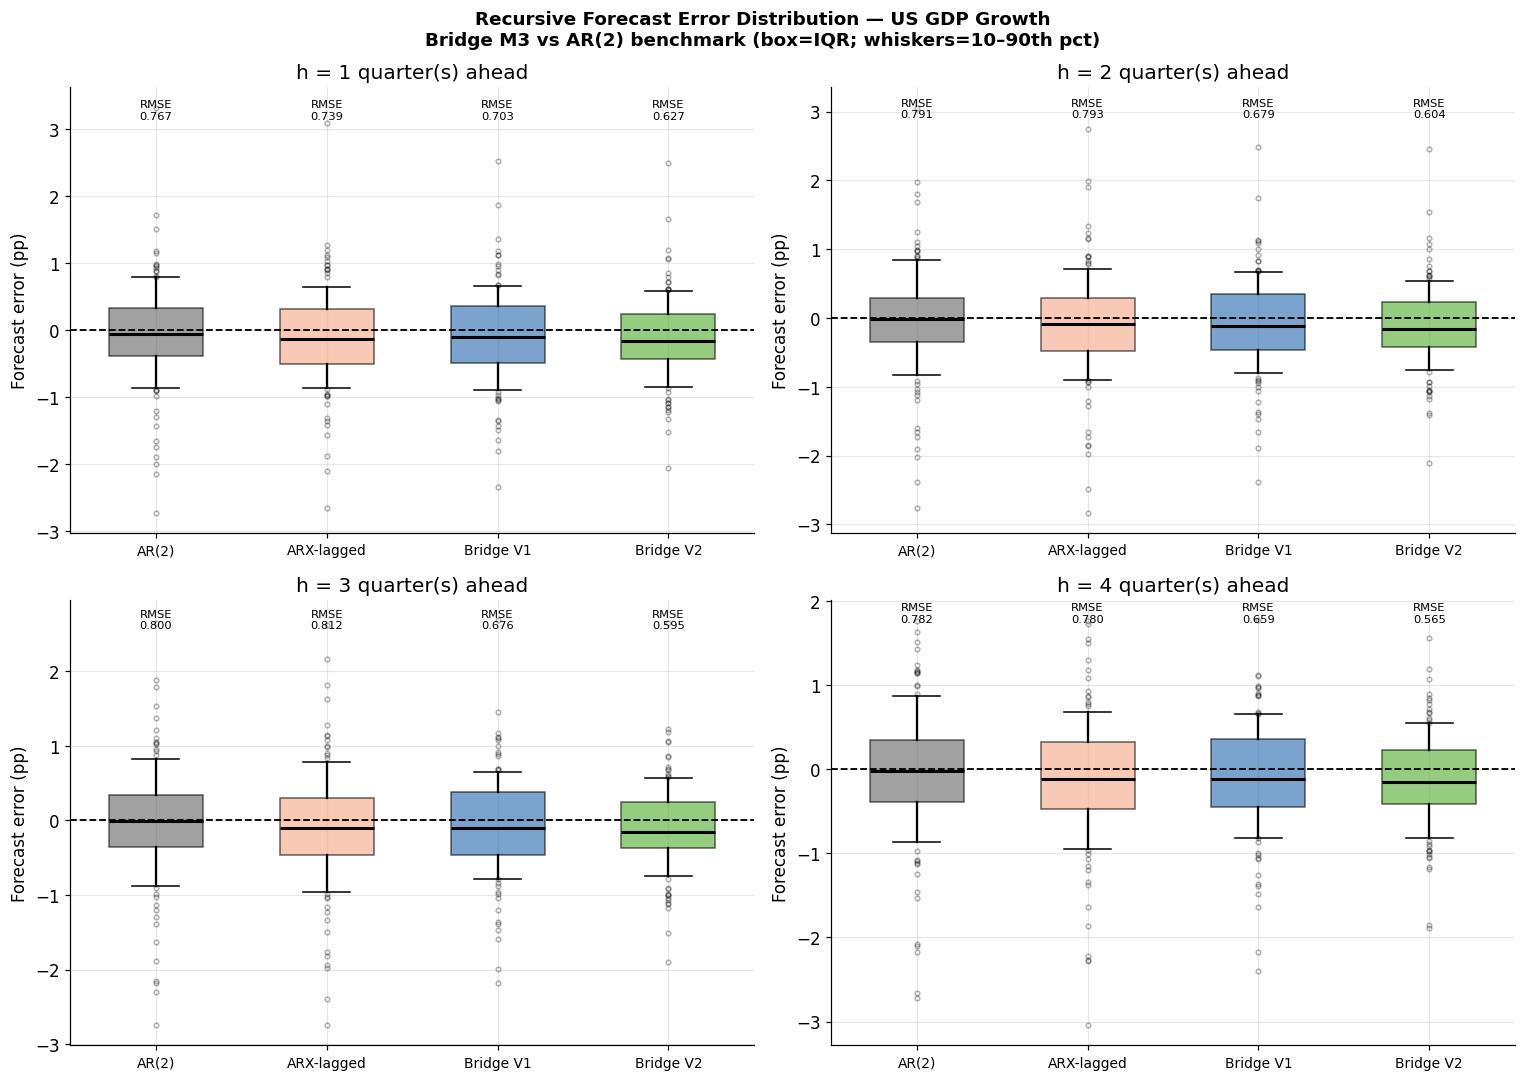

In [16]:
# ── Whisker plots: seminar format ─────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Recursive Forecast Error Distribution — US GDP Growth\n"
             "Bridge M3 vs AR(2) benchmark (box=IQR; whiskers=10–90th pct)",
             fontsize=12, fontweight='bold')

colors_models = {'ar': GREY, 'arx_lag': ORANGE, 'bridge_v1': BLUE, 'bridge_v2': GREEN}
labels_models = {'ar': 'AR(2)', 'arx_lag': 'ARX-lagged',
                 'bridge_v1': 'Bridge V1', 'bridge_v2': 'Bridge V2'}

for ax_idx, h in enumerate([1, 2, 3, 4]):
    ax = axes[ax_idx // 2, ax_idx % 2]
    positions = [1, 2, 3, 4]

    bp_data = [all_results[h][k] for _, k in models]
    bps = ax.boxplot(bp_data, positions=positions, widths=0.55, patch_artist=True,
                     medianprops=dict(color='black', lw=2),
                     whiskerprops=dict(lw=1.5),
                     flierprops=dict(marker='o', ms=3, alpha=0.3),
                     whis=[10, 90])

    for patch, (_, key) in zip(bps['boxes'], models):
        patch.set_facecolor(colors_models[key])
        patch.set_alpha(0.6)

    ax.axhline(0, color='black', lw=1.2, ls='--')
    ax.set_xticks(positions)
    ax.set_xticklabels([labels_models[k] for _, k in models], fontsize=9)
    ax.set_title(f"h = {h} quarter(s) ahead")
    ax.set_ylabel("Forecast error (pp)")

    for pos, (_, key) in zip(positions, models):
        r_val = rmse(all_results[h][key])
        ax.annotate(f"RMSE\n{r_val:.3f}",
                    xy=(pos, ax.get_ylim()[1]*0.87),
                    ha='center', fontsize=7.5, color='black')

plt.tight_layout()
plt.show()

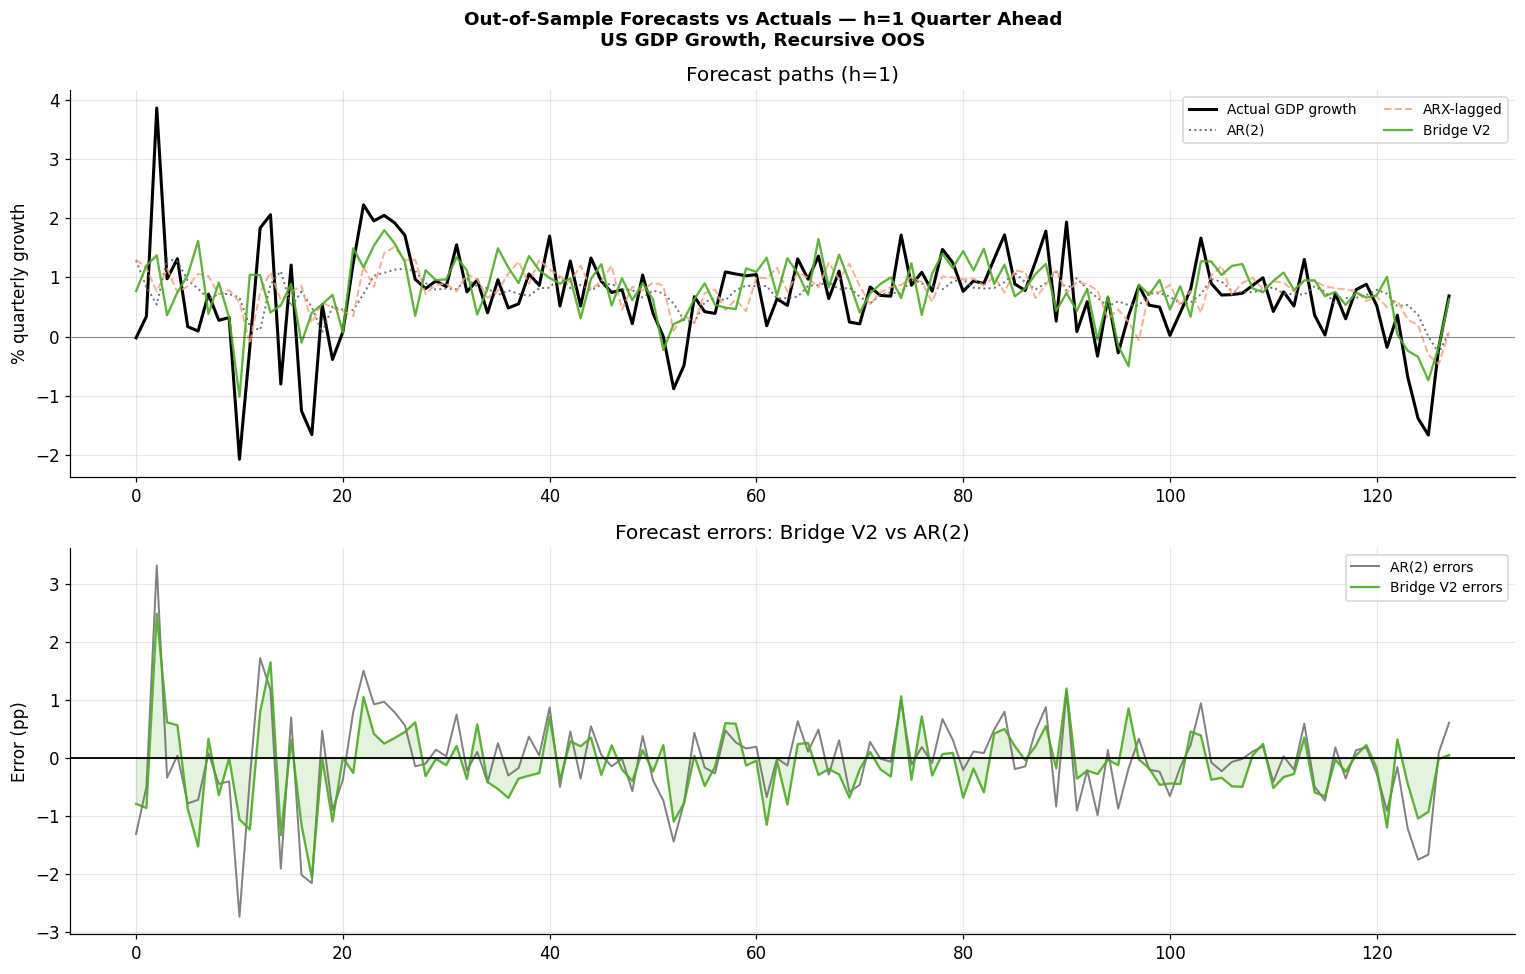

In [17]:
# ── Forecast path plot: actual vs all models, h=1 ────────────────────────────

h = 1
n_obs = len(all_results[h]['ar'])
idx   = range(n_obs)

fig, axes = plt.subplots(2, 1, figsize=(14, 9))
fig.suptitle("Out-of-Sample Forecasts vs Actuals — h=1 Quarter Ahead\n"
             "US GDP Growth, Recursive OOS",
             fontsize=12, fontweight='bold')

# Reconstruct actual series from errors + AR forecast
# actual = ar_error + ar_forecast; since we only stored errors, use df_q
oos_start_idx = next(i for i in range(40, len(df_q)-1)
                     if len(all_results[1]['ar']) > 0)

# Get the actual values corresponding to the OOS period
oos_actuals = []
t_start = None
for t_idx in range(40, len(df_q) - h):
    q_tgt = df_q.index[t_idx + h]
    m1    = q_tgt.to_timestamp(freq='M').to_period('M')
    unemp_avail_check = econ_m['unemp_growth'][:m1-1].dropna()
    if len(unemp_avail_check) >= 10:
        oos_actuals.append(df_q['gdp_growth'].values[t_idx + h])
        if t_start is None:
            t_start = t_idx + h

actual_vals = np.array(oos_actuals[:n_obs])

ax = axes[0]
ax.plot(idx, actual_vals,                       color='black', lw=2.0, label='Actual GDP growth')
ax.plot(idx, actual_vals - all_results[1]['ar'],  color=GREY,   lw=1.3, ls=':', alpha=0.9, label='AR(2)')
ax.plot(idx, actual_vals - all_results[1]['arx_lag'], color=ORANGE, lw=1.3, ls='--', alpha=0.85, label='ARX-lagged')
ax.plot(idx, actual_vals - all_results[1]['bridge_v2'], color=GREEN, lw=1.5, alpha=0.9, label='Bridge V2')
ax.axhline(0, color='black', lw=0.7, alpha=0.4)
ax.set_title("Forecast paths (h=1)")
ax.set_ylabel("% quarterly growth")
ax.legend(fontsize=9, ncol=2)

# Bottom: forecast errors over time for bridge V2 vs AR
ax2 = axes[1]
ax2.plot(idx, all_results[1]['ar'],        color=GREY,  lw=1.3, alpha=0.8, label='AR(2) errors')
ax2.plot(idx, all_results[1]['bridge_v2'], color=GREEN, lw=1.5, alpha=0.9, label='Bridge V2 errors')
ax2.fill_between(idx, 0, all_results[1]['bridge_v2'],
                 alpha=0.15, color=GREEN)
ax2.axhline(0, color='black', lw=1.2)
ax2.set_title("Forecast errors: Bridge V2 vs AR(2)")
ax2.set_ylabel("Error (pp)")
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

---
## Summary — Bridge Equation Checklist and Key Takeaways

### The bridge pipeline

| Step | Action | Key formula |
|------|--------|-------------|
| 1 | Identify a monthly indicator $Z_{t_m}$ for target $y_t$ | Economic rationale + publication timing |
| 2 | Check stationarity of $Z_{t_m}$ | ADF test on monthly series |
| 3 | Estimate monthly AR(p) for $Z_{t_m}$ | Module 1 at monthly frequency |
| 4 | Forecast missing months (ragged edge) | AR h=1 and h=2 from Step 3 |
| 5 | Aggregate: $\bar{Z}_t = \frac{1}{3}(Z_{t,m_1} + \hat{Z}_{t,m_2} + \hat{Z}_{t,m_3})$ | Monthly → quarterly |
| 6 | Estimate quarterly ARX with contemporaneous $\bar{Z}_t$ | $\hat{y}_{t+h\|t} = c + \sum\hat\phi_i y_{t+1-i} + \sum\hat\psi_j\bar{Z}_{t+1-j}$ |
| 7 | Evaluate recursively vs AR and ARX benchmarks | RMSE/MAE by vintage and horizon |

### What the examples taught us

| Finding | Implication |
|---------|-------------|
| Bridge V2 > Bridge V1 > AR at h=1 | More within-quarter data always helps |
| Bridge beats ARX-lagged at short horizons | Within-quarter timeliness is valuable |
| Improvement shrinks at h=3, h=4 | Bridge advantage fades at long horizons |
| Step 1 uncertainty matters | AR-forecast accuracy limits bridge quality |

### What M3 adds over M2

M2 was limited to $Z_{t-1}$ (last quarter's value) because the current quarter's $Z_t$ wasn't available. Bridge equations break this constraint by:

1. Using the freshest available monthly data within the current quarter
2. Filling in missing months with a monthly AR model
3. Converting the result to a quarterly aggregate that can enter a quarterly regression

The cost: two-stage estimation, more complexity, and dependence on the quality of the monthly AR model in Step 1.

---
*Next notebook → Module 4: Random Forest — non-linear forecasting*
